# Fine-tune the STEPP autoencoder on RELLIS-3D (Step 3b)

Port of `STEPP/model/training.py`. Trains the `ReconstructMLP` autoencoder to reconstruct the
**traversable** DINOv2 features from notebook 05 (`features.npy`). High reconstruction error at
inference then means *unfamiliar = untraversable* — but now the notion of "familiar" is learned
from RELLIS terrain instead of forest/synthetic.

- **Architecture:** identical to the pretrained baseline — `ReconstructMLP(384, big_nn)` —
  so the only thing that changes vs. the zero-shot model is the *training domain* (fair comparison).
- **Split:** train on 4 sequences, **hold out 00002** entirely for evaluation (no leakage).
- **Loss:** MSE reconstruction; Adam; early stopping on a validation split of the training data.
- Dropped from the repo version: `wandb` logging and the per-epoch test-image plotting.

Output: a fine-tuned checkpoint to drop into notebook 04 (`CHECKPOINTS`) and evaluate on the
held-out sequence — that image-level traversability comparison is the real payoff (notebook 08).

## 0. Config

In [2]:
import time
from pathlib import Path

OUT_ROOT = Path('s:/#UNIVERSITY/Capstone/Code/Rellis_Stepp/outputs')
CKPT_OUT = OUT_ROOT / 'finetune'
CKPT_OUT.mkdir(parents=True, exist_ok=True)

# pretrained baseline to compare reconstruction against (same big_nn architecture)
PRETRAINED = Path('S:/GIT/STEPP_UnitreeGo2/STEPP_Code_Main/checkpoints/all_ViT_small_input_700_big_nn_checkpoint_20240827-1935.pth')

TRAIN_SEQS = ['00000', '00001', '00003', '00004']   # fine-tune on these
HOLDOUT    = '00002'                                 # never trained on -> for evaluation

BIG_NN        = [256, 128, 64, 32, 64, 128, 256]     # same as the zero-shot checkpoints
BATCH_SIZE    = 256
LR            = 1e-3
MAX_EPOCHS    = 200
PATIENCE      = 15            # early stop after this many epochs without val improvement
VAL_SPLIT     = 0.2
SEED          = 0

RUN_TAG = time.strftime('%Y%m%d-%H%M')
CKPT_PATH = CKPT_OUT / f'rellis_dinov2_big_nn_{RUN_TAG}.pth'
print('train on', TRAIN_SEQS, '| hold out', HOLDOUT, '| checkpoint ->', CKPT_PATH.name)

train on ['00000', '00001', '00003', '00004'] | hold out 00002 | checkpoint -> rellis_dinov2_big_nn_20260614-2204.pth


## 1. Load & combine training features (NaN rows dropped, like the repo)

In [3]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

device = 'cuda' if torch.cuda.is_available() else 'cpu'
torch.manual_seed(SEED); np.random.seed(SEED)
print('device:', device)

def load_features(seqs):
    arrs = []
    for s in seqs:
        a = np.load(OUT_ROOT / s / 'features.npy').astype(np.float32)
        arrs.append(a); print(f'  {s}: {a.shape}')
    X = np.concatenate(arrs, axis=0)
    X = X[~np.isnan(X).any(axis=1)]
    return X

print('loading training features...')
X = load_features(TRAIN_SEQS)
print('combined training set:', X.shape)

Xt = torch.from_numpy(X)
n_val = int(VAL_SPLIT * len(Xt))
perm = torch.randperm(len(Xt), generator=torch.Generator().manual_seed(SEED))
val_x   = Xt[perm[:n_val]].to(device)
train_x = Xt[perm[n_val:]]
train_loader = DataLoader(TensorDataset(train_x), batch_size=BATCH_SIZE, shuffle=True)
print(f'train {len(train_x):,} | val {len(val_x):,}')

device: cuda
loading training features...
  00000: (92614, 384)
  00001: (77517, 384)
  00003: (67853, 384)
  00004: (60257, 384)
combined training set: (298241, 384)
train 238,593 | val 59,648


## 2. Model (identical to the pretrained baseline)

In [4]:
class ReconstructMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super().__init__()
        out = input_dim; layers = []
        for hd in hidden_dim:
            layers += [nn.Linear(input_dim, hd), nn.ReLU()]; input_dim = hd
        layers.append(nn.Linear(input_dim, out))
        self.model = nn.Sequential(*layers)
    def forward(self, x):
        return self.model(x)

model = ReconstructMLP(384, BIG_NN).to(device)
loss_fn = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=LR)
print(model)
print('params:', sum(p.numel() for p in model.parameters()))

ReconstructMLP(
  (model): Sequential(
    (0): Linear(in_features=384, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): ReLU()
    (6): Linear(in_features=64, out_features=32, bias=True)
    (7): ReLU()
    (8): Linear(in_features=32, out_features=64, bias=True)
    (9): ReLU()
    (10): Linear(in_features=64, out_features=128, bias=True)
    (11): ReLU()
    (12): Linear(in_features=128, out_features=256, bias=True)
    (13): ReLU()
    (14): Linear(in_features=256, out_features=384, bias=True)
  )
)
params: 283936


## 3. Train with early stopping (saves the best-val checkpoint)

In [5]:
@torch.no_grad()
def val_loss():
    model.eval()
    return loss_fn(model(val_x), val_x).item()

hist = {'train': [], 'val': []}
best_val, best_epoch, wait = float('inf'), -1, 0
t0 = time.time()
for epoch in range(MAX_EPOCHS):
    model.train(); running = 0.0
    for (b,) in train_loader:
        b = b.to(device)
        optimizer.zero_grad()
        loss = loss_fn(model(b), b)
        loss.backward(); optimizer.step()
        running += loss.item()
    tr = running / len(train_loader)
    vl = val_loss()
    hist['train'].append(tr); hist['val'].append(vl)

    if vl < best_val - 1e-5:
        best_val, best_epoch, wait = vl, epoch, 0
        torch.save(model.state_dict(), CKPT_PATH)
    else:
        wait += 1
    if epoch % 5 == 0 or wait == 0:
        print(f'epoch {epoch+1:3d} | train {tr:.4f} | val {vl:.4f} | best {best_val:.4f} (ep {best_epoch+1})')
    if wait >= PATIENCE:
        print(f'early stopping at epoch {epoch+1} (no val improvement for {PATIENCE} epochs)')
        break

print(f'\ndone in {time.time()-t0:.0f}s | best val MSE {best_val:.4f} @ epoch {best_epoch+1}')
print('saved best checkpoint ->', CKPT_PATH)
model.load_state_dict(torch.load(CKPT_PATH, map_location=device))   # restore best

epoch   1 | train 1.0947 | val 0.7209 | best 0.7209 (ep 1)
epoch   2 | train 0.5053 | val 0.5714 | best 0.5714 (ep 2)
epoch   3 | train 0.3846 | val 0.5178 | best 0.5178 (ep 3)
epoch   4 | train 0.3435 | val 0.5166 | best 0.5166 (ep 4)
epoch   5 | train 0.3179 | val 0.4257 | best 0.4257 (ep 5)
epoch   6 | train 0.3020 | val 0.4833 | best 0.4257 (ep 5)
epoch   8 | train 0.2839 | val 0.3252 | best 0.3252 (ep 8)
epoch  11 | train 0.2642 | val 0.4067 | best 0.3252 (ep 8)
epoch  16 | train 0.2491 | val 0.3178 | best 0.3178 (ep 16)
epoch  21 | train 0.2392 | val 0.4112 | best 0.3178 (ep 16)
epoch  25 | train 0.2350 | val 0.2951 | best 0.2951 (ep 25)
epoch  26 | train 0.2328 | val 0.2744 | best 0.2744 (ep 26)
epoch  31 | train 0.2282 | val 0.2819 | best 0.2744 (ep 26)
epoch  36 | train 0.2244 | val 0.2839 | best 0.2744 (ep 26)
epoch  41 | train 0.2242 | val 0.3455 | best 0.2744 (ep 26)
early stopping at epoch 41 (no val improvement for 15 epochs)

done in 148s | best val MSE 0.2744 @ epoch 26

C:\Users\jthre\AppData\Local\Temp\ipykernel_37856\2668539405.py:34: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(CKPT_PATH, map_location=de

<All keys matched successfully>

## 4. Loss curves

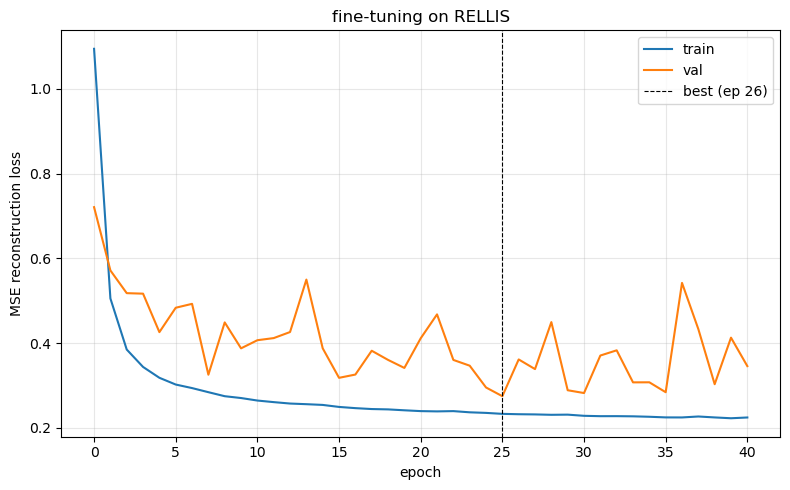

In [6]:
plt.figure(figsize=(8, 5))
plt.plot(hist['train'], label='train')
plt.plot(hist['val'], label='val')
plt.axvline(best_epoch, color='k', ls='--', lw=0.8, label=f'best (ep {best_epoch+1})')
plt.xlabel('epoch'); plt.ylabel('MSE reconstruction loss'); plt.title('fine-tuning on RELLIS')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig(CKPT_OUT / f'loss_{RUN_TAG}.png', dpi=120); plt.show()

## 5. Held-out sanity: does fine-tuning reconstruct RELLIS traversable features better?

Compare mean reconstruction MSE on the **held-out 00002** traversable segments (which neither
model trained on) for the forest/synthetic **pretrained** model vs. our **fine-tuned** model.
Lower = the model finds RELLIS traversable terrain more 'familiar'. (This only checks the
positive class; the full traversable-vs-not metric comes from notebook 04 on 00002.)

In [7]:
Xh = torch.from_numpy(load_features([HOLDOUT])).to(device)
pre = ReconstructMLP(384, BIG_NN).to(device)
pre.load_state_dict(torch.load(PRETRAINED, map_location=device)); pre.eval()

@torch.no_grad()
def mean_recon(m):
    return nn.MSELoss(reduction='none')(m(Xh), Xh).mean(1).mean().item()

err_pre, err_ft = mean_recon(pre), mean_recon(model)
print(f'held-out {HOLDOUT} mean recon MSE on traversable segments:')
print(f'  pretrained (all_data, forest+synthetic): {err_pre:.4f}')
print(f'  fine-tuned (RELLIS)                     : {err_ft:.4f}')
print(f'  -> {"improved" if err_ft < err_pre else "NOT improved"} '
      f'({100*(err_pre-err_ft)/err_pre:+.1f}% vs pretrained)')

  00002: (186383, 384)
held-out 00002 mean recon MSE on traversable segments:
  pretrained (all_data, forest+synthetic): 1.2707
  fine-tuned (RELLIS)                     : 1.0864
  -> improved (+14.5% vs pretrained)


C:\Users\jthre\AppData\Local\Temp\ipykernel_37856\2703030123.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  pre.load_state_dict(torch.load(PRETRAINED, map_location=devi

## 6. Save run metadata

In [8]:
import json
meta = {
    'checkpoint': CKPT_PATH.name, 'run_tag': RUN_TAG,
    'train_seqs': TRAIN_SEQS, 'holdout': HOLDOUT,
    'architecture': BIG_NN, 'batch_size': BATCH_SIZE, 'lr': LR,
    'max_epochs': MAX_EPOCHS, 'patience': PATIENCE, 'val_split': VAL_SPLIT,
    'n_train_segments': int(len(train_x)), 'n_val_segments': int(len(val_x)),
    'best_val_mse': float(best_val), 'best_epoch': int(best_epoch + 1),
    'holdout_recon_pretrained': float(err_pre), 'holdout_recon_finetuned': float(err_ft),
}
json.dump(meta, open(CKPT_OUT / f'meta_{RUN_TAG}.json', 'w'), indent=2)
print(json.dumps(meta, indent=2))
print('\nNext: add this checkpoint to notebook 04 CHECKPOINTS and run it with SEQS=["00002"]')
print('to compare fine-tuned vs zero-shot traversability (IoU / ROC-AUC) on the held-out sequence.')

{
  "checkpoint": "rellis_dinov2_big_nn_20260614-2204.pth",
  "run_tag": "20260614-2204",
  "train_seqs": [
    "00000",
    "00001",
    "00003",
    "00004"
  ],
  "holdout": "00002",
  "architecture": [
    256,
    128,
    64,
    32,
    64,
    128,
    256
  ],
  "batch_size": 256,
  "lr": 0.001,
  "max_epochs": 200,
  "patience": 15,
  "val_split": 0.2,
  "n_train_segments": 238593,
  "n_val_segments": 59648,
  "best_val_mse": 0.27444982528686523,
  "best_epoch": 26,
  "holdout_recon_pretrained": 1.2707178592681885,
  "holdout_recon_finetuned": 1.0864442586898804
}

Next: add this checkpoint to notebook 04 CHECKPOINTS and run it with SEQS=["00002"]
to compare fine-tuned vs zero-shot traversability (IoU / ROC-AUC) on the held-out sequence.
